# DRL Assignment 1 - Part 2: Dynamic Programming

This notebook implements the custom Drone Rescue grid-world and solves it with Value Iteration.

What this notebook includes:
- a finite MDP environment with battery, rescue, danger, charging, wind, and blocked cells
- state enumeration and value iteration with a stopping threshold of `1e-3`
- policy visualisation, rollout visualisation, and a state-value heatmap
- a short scalability discussion about the curse of dimensionality

Replace the default `IDENTIFIER` in the final run cell with your group ID or the first student's register number.
The last digit controls the environment configuration, as described in the assignment.


## Environment model

The code below defines the grid layout, the state representation, the transition model,
and the helper used to print the assignment-required timestamp and machine identifier.

The drone state tracks position, battery level, and which rescue targets have already been rescued.


In [36]:
"""Deep Reinforcement Learning assignment, Part 2: Dynamic Programming.

This script implements the custom Drone Rescue environment and solves it with
Value Iteration. It also creates the requested policy and value visualisations.

The environment configuration is determined by the last digit of the provided
identifier. The assignment text refers to the group ID / first student's
register number, so this script accepts either as a single identifier string.
"""

from __future__ import annotations

import argparse
import socket
from collections import deque
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from time import perf_counter
from typing import Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np


@dataclass(frozen=True)
class DroneState:
    """Compact state representation: position, battery, and rescued targets."""

    row: int
    col: int
    battery: int
    rescued_mask: int


class DroneRescueEnv:
    """Custom finite MDP for the drone rescue assignment."""

    ACTIONS = ("UP", "DOWN", "LEFT", "RIGHT", "HOVER")
    MOVE_ACTIONS = ("UP", "DOWN", "LEFT", "RIGHT")
    DELTAS = {
        "UP": (-1, 0),
        "DOWN": (1, 0),
        "LEFT": (0, -1),
        "RIGHT": (0, 1),
        "HOVER": (0, 0),
    }
    ACTION_TO_ARROW = {
        "UP": "↑",
        "DOWN": "↓",
        "LEFT": "←",
        "RIGHT": "→",
        "HOVER": "•",
    }

    def __init__(self, identifier: str) -> None:
        """Build the grid, place special cells, and prepare the MDP."""

        self.identifier = str(identifier)
        self.last_digit = self._extract_last_digit(self.identifier)

        self.grid_size = 5 if self.last_digit <= 4 else 6
        self.num_rescue_targets = 2 if self.last_digit <= 4 else 3
        self.num_charging_stations = 1 if self.last_digit <= 4 else 2
        self.num_danger_zones = 3 if self.last_digit <= 4 else 4
        self.num_blocked_cells = 2 if self.last_digit <= 4 else 3
        self.num_wind_zones = 2 if self.grid_size == 5 else 3

        self.wind_probability = 0.20 if self.last_digit <= 4 else 0.30
        self.max_battery = 10 if (self.last_digit % 2 == 0) else 15
        self.max_steps = 50 if self.grid_size == 5 else 75
        self.discount_factor = 0.95
        self.theta = 1e-3
        self.start_position = (0, 0)

        self.rng = np.random.default_rng(self._stable_seed(self.identifier))
        self._transition_cache: Dict[Tuple[DroneState, str], Tuple[Tuple[float, DroneState, float, bool], ...]] = {}

        self._build_layout()
        self.current_state = self.initial_state()
        self.steps_taken = 0

    @staticmethod
    def _extract_last_digit(identifier: str) -> int:
        """Return the last numeric digit in the provided identifier."""

        for char in reversed(identifier):
            if char.isdigit():
                return int(char)
        return 0

    @staticmethod
    def _stable_seed(identifier: str) -> int:
        """Create a deterministic seed without relying on Python's hash randomization."""

        value = 0
        for char in identifier:
            value = (value * 131 + ord(char)) % (2**32)
        return value

    def _build_layout(self) -> None:
        """Place the special cells deterministically but ensure rescue targets are reachable."""

        # Start with all non-start cells
        all_cells = [(r, c) for r in range(self.grid_size) for c in range(self.grid_size) if (r, c) != self.start_position]
        self.rng.shuffle(all_cells)

        # Simple static reachability (ignore battery and wind)
        def reachable_from_start(blocked_set: set) -> set:
            q = deque([self.start_position])
            vis = {self.start_position}
            while q:
                r, c = q.popleft()
                for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < self.grid_size and 0 <= nc < self.grid_size and (nr, nc) not in blocked_set and (nr, nc) not in vis:
                        vis.add((nr, nc))
                        q.append((nr, nc))
            return vis

        # Reserve some cells deterministically for wind, danger and charging
        pool = list(all_cells)

        def take_from_pool(count: int) -> List[Tuple[int, int]]:
            taken = []
            while count > 0 and pool:
                taken.append(pool.pop(0))
                count -= 1
            return taken

        self.wind_zones = take_from_pool(self.num_wind_zones)
        self.danger_zones = take_from_pool(self.num_danger_zones)
        self.charging_stations = take_from_pool(self.num_charging_stations)

        # Choose blocked cells carefully so they don't isolate the grid
        blocked_set = set()
        remaining_blocked = self.num_blocked_cells

        # Candidates for blocking are the remaining pool
        blocked_candidates = list(pool)
        self.rng.shuffle(blocked_candidates)

        for cand in blocked_candidates:
            if remaining_blocked <= 0:
                break
            blocked_set.add(cand)
            vis = reachable_from_start(blocked_set)
            # require that there are at least num_rescue_targets reachable cells besides start
            if len(vis) - 1 < self.num_rescue_targets:
                blocked_set.remove(cand)
                continue
            remaining_blocked -= 1

        self.blocked_cells = list(blocked_set)

        # Select rescue targets from reachable cells (excluding start and blocked)
        reachable_cells = sorted(list(reachable_from_start(set(self.blocked_cells))))
        reachable_candidates = [c for c in reachable_cells if c != self.start_position]

        # Fallback if not enough reachable candidates
        if len(reachable_candidates) < self.num_rescue_targets:
            reachable_candidates = [c for c in all_cells if c != self.start_position and c not in self.blocked_cells]

        self.rescue_targets = reachable_candidates[: self.num_rescue_targets]

        # Build rescue index
        self.rescue_index = {position: idx for idx, position in enumerate(self.rescue_targets)}

        # Build base layout
        self.base_layout = np.full((self.grid_size, self.grid_size), "F", dtype="<U1")
        self.base_layout[self.start_position] = "S"
        for row, col in self.rescue_targets:
            self.base_layout[row, col] = "R"
        for row, col in self.charging_stations:
            self.base_layout[row, col] = "C"
        for row, col in self.danger_zones:
            self.base_layout[row, col] = "D"
        for row, col in self.blocked_cells:
            self.base_layout[row, col] = "X"
        for row, col in self.wind_zones:
            self.base_layout[row, col] = "W"

    def describe_configuration(self) -> None:
        """Print the grid configuration and symbol legend."""

        print(f"Identifier / group code : {self.identifier}")
        print(f"Last digit              : {self.last_digit}")
        print(f"Grid size               : {self.grid_size} x {self.grid_size}")
        print(f"Max battery             : {self.max_battery}")
        print(f"Wind probability        : {self.wind_probability:.0%}")
        print(f"Maximum episode length   : {self.max_steps}")
        print(f"Discount factor gamma    : {self.discount_factor}")
        print("\nCell placement")
        print(f"  Start position         : {self.start_position}")
        print(f"  Rescue targets         : {self.rescue_targets}")
        print(f"  Charging stations      : {self.charging_stations}")
        print(f"  Danger zones           : {self.danger_zones}")
        print(f"  Blocked cells          : {self.blocked_cells}")
        print(f"  Wind zones             : {self.wind_zones}")
        print("\nLegend: S start, F free, D danger, R rescue, C charging, W wind, X blocked")
        print("\nBase grid:")
        self.render(self.initial_state())

    def _in_bounds(self, row: int, col: int) -> bool:
        """Check whether a candidate cell is inside the grid."""

        return 0 <= row < self.grid_size and 0 <= col < self.grid_size

    def _base_symbol(self, row: int, col: int) -> str:
        """Return the static symbol for a cell, ignoring rescued target state."""

        return str(self.base_layout[row, col])

    def cell_symbol(self, row: int, col: int, rescued_mask: int) -> str:
        """Return the visible symbol for a cell under the current rescue mask."""

        if (row, col) == self.start_position:
            return "S"

        if (row, col) in self.rescue_index:
            bit = self.rescue_index[(row, col)]
            if rescued_mask & (1 << bit):
                return "F"
            return "R"

        return self._base_symbol(row, col)

    def grid_symbols(self, rescued_mask: int) -> List[List[str]]:
        """Build the current grid as a nested list of symbols."""

        return [[self.cell_symbol(row, col, rescued_mask) for col in range(self.grid_size)] for row in range(self.grid_size)]

    def initial_state(self) -> DroneState:
        """Return the starting state with full battery and no rescued civilians."""

        return DroneState(row=0, col=0, battery=self.max_battery, rescued_mask=0)

    def reset(self) -> DroneState:
        """Reset the environment to the initial state."""

        self.current_state = self.initial_state()
        self.steps_taken = 0
        return self.current_state

    def is_terminal(self, state: DroneState) -> bool:
        """Check terminal conditions: battery depletion or all rescues completed."""

        all_rescued = state.rescued_mask == (1 << self.num_rescue_targets) - 1
        return state.battery <= 0 or all_rescued

    def valid_actions(self, state: DroneState) -> List[str]:
        """Return all modelled actions unless the state is terminal."""

        if self.is_terminal(state):
            return []
        return list(self.ACTIONS)

    def _apply_actual_action(self, state: DroneState, actual_action: str) -> Tuple[DroneState, float, bool]:
        """Apply one concrete movement after any wind disturbance."""

        current_symbol = self.cell_symbol(state.row, state.col, state.rescued_mask)

        next_row, next_col = state.row, state.col
        moved = False
        if actual_action != "HOVER":
            delta_row, delta_col = self.DELTAS[actual_action]
            candidate_row = state.row + delta_row
            candidate_col = state.col + delta_col
            if self._in_bounds(candidate_row, candidate_col) and self._base_symbol(candidate_row, candidate_col) != "X":
                next_row, next_col = candidate_row, candidate_col
                moved = (next_row, next_col) != (state.row, state.col)

        # The assignment prioritises the charging exception, so hovering on C is a recharge action.
        if actual_action == "HOVER" and current_symbol == "C":
            reward = 0.0
            next_battery = min(self.max_battery, state.battery + 2)
        else:
            reward = -1.0
            next_battery = state.battery - 1

        next_mask = state.rescued_mask
        next_symbol = self.cell_symbol(next_row, next_col, next_mask)

        rescue_bit = self.rescue_index.get((next_row, next_col))
        if rescue_bit is not None and not (next_mask & (1 << rescue_bit)):
            reward += 20.0
            next_mask |= 1 << rescue_bit
            next_symbol = "F"

        if next_symbol == "D":
            reward -= 10.0

        if next_symbol == "C" and actual_action != "HOVER" and moved:
            reward += 5.0
            next_battery = self.max_battery

        if next_battery <= 0:
            reward -= 20.0
            return DroneState(next_row, next_col, 0, next_mask), reward, True

        return DroneState(next_row, next_col, next_battery, next_mask), reward, False

    def transition_model(self, state: DroneState, action: str) -> Tuple[Tuple[float, DroneState, float, bool], ...]:
        """Return the stochastic transition model for a given state-action pair."""

        cache_key = (state, action)
        if cache_key in self._transition_cache:
            return self._transition_cache[cache_key]

        if self.is_terminal(state):
            transitions = ((1.0, state, 0.0, True),)
            self._transition_cache[cache_key] = transitions
            return transitions

        current_symbol = self.cell_symbol(state.row, state.col, state.rescued_mask)
        outcomes: Dict[Tuple[DroneState, float, bool], float] = {}

        if current_symbol == "W" and action in self.MOVE_ACTIONS:
            actual_action_probabilities = {move: self.wind_probability / 4.0 for move in self.MOVE_ACTIONS}
            actual_action_probabilities[action] += 1.0 - self.wind_probability
        else:
            actual_action_probabilities = {action: 1.0}

        for actual_action, probability in actual_action_probabilities.items():
            next_state, reward, done = self._apply_actual_action(state, actual_action)
            key = (next_state, reward, done)
            outcomes[key] = outcomes.get(key, 0.0) + probability

        transitions = tuple((prob, next_state, reward, done) for (next_state, reward, done), prob in outcomes.items())
        self._transition_cache[cache_key] = transitions
        return transitions

    def step(self, action: str) -> Tuple[DroneState, float, bool, Dict[str, object]]:
        """Sample one transition from the MDP and update the live environment state."""

        transitions = self.transition_model(self.current_state, action)
        probabilities = np.array([entry[0] for entry in transitions], dtype=float)
        probabilities = probabilities / probabilities.sum()

        choice = int(self.rng.choice(len(transitions), p=probabilities))
        probability, next_state, reward, done = transitions[choice]

        self.current_state = next_state
        self.steps_taken += 1

        info = {
            "chosen_action": action,
            "sampled_probability": float(probability),
            "steps_taken": self.steps_taken,
        }
        return next_state, reward, done, info

    def render(self, state: Optional[DroneState] = None) -> None:
        """Print a text rendering of the current grid and drone position."""

        if state is None:
            state = self.current_state

        grid = self.grid_symbols(state.rescued_mask)
        grid[state.row][state.col] = "A"

        print("Grid view:")
        for row in grid:
            print(" ".join(row))
        print(f"Drone state: row={state.row}, col={state.col}, battery={state.battery}, rescued_mask={bin(state.rescued_mask)}")

    def enumerate_reachable_states(self) -> List[DroneState]:
        """Breadth-first enumeration of all states reachable from the start."""

        start_state = self.initial_state()
        visited = {start_state}
        queue = deque([start_state])

        while queue:
            state = queue.popleft()
            if self.is_terminal(state):
                continue

            for action in self.valid_actions(state):
                for _, next_state, _, _ in self.transition_model(state, action):
                    if next_state not in visited:
                        visited.add(next_state)
                        queue.append(next_state)

        return sorted(visited, key=lambda s: (s.row, s.col, s.battery, s.rescued_mask))


## Dynamic programming solver and visualisations

This cell contains Value Iteration plus the policy, rollout, and heatmap plotting helpers.

The environment is solved over the reachable state space, and the resulting policy is visualised for a fixed
battery level and rescue-mask slice so that the assignment output is easy to interpret.


In [37]:
def print_execution_banner(identifier: str) -> None:
    """Print the timestamp and machine identifier for the notebook header."""

    timestamp = datetime.now().astimezone().strftime("%Y-%m-%d %H:%M:%S %Z")
    machine_id = socket.gethostname()

    print("=" * 88)
    print("Deep Reinforcement Learning - Part 2: Dynamic Programming")
    print(f"Identifier   : {identifier}")
    print(f"Timestamp    : {timestamp}")
    print(f"Machine ID   : {machine_id}")
    print("=" * 88)


def value_iteration(
    env: DroneRescueEnv,
    gamma: float = 0.95,
    theta: float = 1e-3,
) -> Tuple[Dict[DroneState, float], Dict[DroneState, str], Dict[str, float]]:
    """Run value iteration on the reachable state space."""

    reachable_states = env.enumerate_reachable_states()
    values: Dict[DroneState, float] = {state: 0.0 for state in reachable_states}
    policy: Dict[DroneState, str] = {}

    start_time = perf_counter()
    iterations = 0
    final_delta = 0.0

    while True:
        delta = 0.0
        updated_values: Dict[DroneState, float] = {}

        for state in reachable_states:
            if env.is_terminal(state):
                updated_values[state] = 0.0
                policy[state] = "HOVER"
                continue

            q_values: Dict[str, float] = {}
            for action in env.valid_actions(state):
                q_value = 0.0
                for probability, next_state, reward, done in env.transition_model(state, action):
                    q_value += probability * (reward + gamma * values[next_state])
                q_values[action] = q_value

            best_action = max(q_values, key=q_values.get)
            updated_values[state] = q_values[best_action]
            policy[state] = best_action
            delta = max(delta, abs(updated_values[state] - values[state]))

        values = updated_values
        iterations += 1
        final_delta = delta
        if delta < theta:
            break

    runtime_seconds = perf_counter() - start_time
    stats = {
        "iterations": float(iterations),
        "runtime_seconds": float(runtime_seconds),
        "final_delta": float(final_delta),
        "reachable_states": float(len(reachable_states)),
    }
    return values, policy, stats


def plot_policy_slice(
    env: DroneRescueEnv,
    policy: Dict[DroneState, str],
    fixed_battery: int,
    fixed_rescue_mask: int,
    output_path: Path,
    show_plot: bool = False,
) -> None:
    """Visualise the optimal policy as arrows on a fixed state slice."""

    symbol_to_code = {"S": 0, "F": 1, "D": 2, "R": 3, "C": 4, "W": 5, "X": 6}
    colors = [
        "#2E8B57",  # S
        "#F1F1F1",  # F
        "#D95F02",  # D
        "#E7298A",  # R
        "#1F78B4",  # C
        "#7570B3",  # W
        "#1A1A1A",  # X
    ]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, 7.5, 1), cmap.N)

    grid_codes = np.zeros((env.grid_size, env.grid_size), dtype=int)
    for row in range(env.grid_size):
        for col in range(env.grid_size):
            symbol = env.cell_symbol(row, col, fixed_rescue_mask)
            grid_codes[row, col] = symbol_to_code[symbol]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(grid_codes, cmap=cmap, norm=norm)

    ax.set_xticks(np.arange(env.grid_size))
    ax.set_yticks(np.arange(env.grid_size))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(color="black", linestyle="-", linewidth=1, alpha=0.45)
    ax.set_title(f"Optimal Policy Slice | battery={fixed_battery}, rescued_mask={bin(fixed_rescue_mask)}")

    for row in range(env.grid_size):
        for col in range(env.grid_size):
            symbol = env.cell_symbol(row, col, fixed_rescue_mask)
            state = DroneState(row=row, col=col, battery=fixed_battery, rescued_mask=fixed_rescue_mask)
            action = policy.get(state, None)
            arrow = DroneRescueEnv.ACTION_TO_ARROW.get(action, "·")

            if symbol == "X":
                label = "X"
                text_color = "white"
            elif symbol == "S":
                label = f"S\n{arrow}"
                text_color = "black"
            elif symbol == "R":
                label = f"R\n{arrow}"
                text_color = "white"
            elif symbol == "C":
                label = f"C\n{arrow}"
                text_color = "white"
            elif symbol == "D":
                label = f"D\n{arrow}"
                text_color = "white"
            elif symbol == "W":
                label = f"W\n{arrow}"
                text_color = "white"
            else:
                label = arrow
                text_color = "black"

            ax.text(col, row, label, ha="center", va="center", fontsize=12, color=text_color, fontweight="bold")

    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    if show_plot:
        plt.show()
    plt.close()


def simulate_optimal_rollout(
    env: DroneRescueEnv,
    policy: Dict[DroneState, str],
    max_steps: Optional[int] = None,
) -> Tuple[List[DroneState], List[str], List[float]]:
    """Roll out the greedy optimal policy in the live environment."""

    if max_steps is None:
        max_steps = env.max_steps

    state = env.reset()
    trajectory = [state]
    actions: List[str] = []
    rewards: List[float] = []

    for _ in range(max_steps):
        action = policy.get(state, "HOVER")
        next_state, reward, done, _ = env.step(action)
        trajectory.append(next_state)
        actions.append(action)
        rewards.append(reward)
        state = next_state
        if done:
            break

    return trajectory, actions, rewards


def plot_optimal_trajectory(
    env: DroneRescueEnv,
    trajectory: List[DroneState],
    output_path: Path,
    show_plot: bool = False,
) -> None:
    """Plot the state trajectory produced by the optimal policy rollout."""

    symbol_to_code = {"S": 0, "F": 1, "D": 2, "R": 3, "C": 4, "W": 5, "X": 6}
    colors = [
        "#2E8B57",
        "#F1F1F1",
        "#D95F02",
        "#E7298A",
        "#1F78B4",
        "#7570B3",
        "#1A1A1A",
    ]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, 7.5, 1), cmap.N)

    start_mask = 0
    grid_codes = np.zeros((env.grid_size, env.grid_size), dtype=int)
    for row in range(env.grid_size):
        for col in range(env.grid_size):
            symbol = env.cell_symbol(row, col, start_mask)
            grid_codes[row, col] = symbol_to_code[symbol]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(grid_codes, cmap=cmap, norm=norm)
    ax.set_xticks(np.arange(env.grid_size))
    ax.set_yticks(np.arange(env.grid_size))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(color="black", linestyle="-", linewidth=1, alpha=0.45)
    ax.set_title("Optimal Policy Rollout")

    rows = [state.row for state in trajectory]
    cols = [state.col for state in trajectory]
    ax.plot(cols, rows, color="white", linewidth=2.5, marker="o", markersize=4)

    for step, state in enumerate(trajectory):
        ax.text(state.col, state.row, str(step), ha="center", va="center", fontsize=10, color="black", fontweight="bold")

    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    if show_plot:
        plt.show()
    plt.close()


def plot_state_value_heatmap(
    env: DroneRescueEnv,
    values: Dict[DroneState, float],
    fixed_battery: int,
    fixed_rescue_mask: int,
    output_path: Path,
    show_plot: bool = False,
) -> None:
    """Plot a heatmap for a meaningful slice of V*(s)."""

    value_grid = np.full((env.grid_size, env.grid_size), np.nan, dtype=float)

    for row in range(env.grid_size):
        for col in range(env.grid_size):
            state = DroneState(row=row, col=col, battery=fixed_battery, rescued_mask=fixed_rescue_mask)
            if state in values:
                value_grid[row, col] = values[state]

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(value_grid, cmap="viridis")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="State value")

    ax.set_xticks(np.arange(env.grid_size))
    ax.set_yticks(np.arange(env.grid_size))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(color="white", linestyle="-", linewidth=1, alpha=0.35)
    ax.set_title(f"Value Function Slice | battery={fixed_battery}, rescued_mask={bin(fixed_rescue_mask)}")

    for row in range(env.grid_size):
        for col in range(env.grid_size):
            value = value_grid[row, col]
            if not np.isnan(value):
                ax.text(col, row, f"{value:.1f}", ha="center", va="center", fontsize=9, color="white")

    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    if show_plot:
        plt.show()
    plt.close()


SCALABILITY_DISCUSSION = """
Curse of dimensionality:
* If the grid expands from 5x5 or 6x6 to 10x10, the position component alone grows from
  25/36 cells to 100 cells, which multiplies the state count immediately.
* Each additional rescue target doubles the mask dimension, because the target status is
  part of the MDP state. Three targets already create 2^3 = 8 rescue-status combinations;
  five targets would create 32.
* If weather becomes dynamic instead of being attached to fixed wind cells, the transition
  model must include the weather state as well, which further increases the state space.

Why DP becomes difficult:
* Value iteration needs to sweep over every reachable state repeatedly until convergence.
* The number of states and transitions grows quickly, so memory and runtime both increase.
* On a larger grid with more targets, the exact state-space enumeration becomes expensive.

How Deep RL helps:
* Deep RL can approximate the value function or policy with a neural network instead of
  storing every state explicitly.
* That reduces the need to enumerate the full state space and can generalise across similar
  states.
* For real autonomous drone systems, this is a more realistic path once the environment is
  too large for exact DP.
""".strip()


def print_scalability_discussion() -> None:
    """Print the scalability notes requested in the assignment."""

    print("\nScalability discussion:")
    print(SCALABILITY_DISCUSSION)


def run_dp_workflow(
    identifier: str,
    output_dir: Path | str = Path("outputs") / "dp",
    gamma: float = 0.95,
    theta: float = 1e-3,
    show_plots: bool = False,
) -> Dict[str, object]:
    """Run the full DP pipeline: environment, planning, and visualisation."""

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print_execution_banner(identifier)
    env = DroneRescueEnv(identifier)
    env.describe_configuration()

    print("\nRunning value iteration...")
    values, policy, stats = value_iteration(env, gamma=gamma, theta=theta)
    print(
        f"Converged in {int(stats['iterations'])} iterations | "
        f"runtime = {stats['runtime_seconds']:.3f} s | "
        f"final delta = {stats['final_delta']:.6f} | "
        f"reachable states = {int(stats['reachable_states'])}"
    )

    fixed_battery = env.max_battery
    fixed_mask = 0

    policy_path = output_dir / "dp_policy_slice.png"
    rollout_path = output_dir / "dp_optimal_rollout.png"
    heatmap_path = output_dir / "dp_value_heatmap.png"

    plot_policy_slice(env, policy, fixed_battery, fixed_mask, policy_path, show_plot=show_plots)

    trajectory, actions, rewards = simulate_optimal_rollout(env, policy)
    plot_optimal_trajectory(env, trajectory, rollout_path, show_plot=show_plots)
    plot_state_value_heatmap(env, values, fixed_battery, fixed_mask, heatmap_path, show_plot=show_plots)

    total_reward = float(sum(rewards))
    rescued_count = bin(trajectory[-1].rescued_mask).count("1")
    print(f"\nOptimal rollout summary:")
    print(f"  Steps taken        : {len(actions)}")
    print(f"  Total rollout reward: {total_reward:.3f}")
    print(f"  Rescued civilians   : {rescued_count} / {env.num_rescue_targets}")
    print(f"  Final battery       : {trajectory[-1].battery}")
    print(f"  Final position      : ({trajectory[-1].row}, {trajectory[-1].col})")

    print(f"\nSaved policy slice to  : {policy_path}")
    print(f"Saved rollout plot to  : {rollout_path}")
    print(f"Saved heatmap to       : {heatmap_path}")

    print_scalability_discussion()

    return {
        "environment": env,
        "values": values,
        "policy": policy,
        "stats": stats,
        "trajectory": trajectory,
        "actions": actions,
        "rewards": rewards,
    }


## Run the notebook

Set the identifier for your submission and execute the cell below.
The notebook will print convergence statistics, save the visualisations, and show the rollout summary.


Deep Reinforcement Learning - Part 2: Dynamic Programming
Identifier   : 129
Timestamp    : 2026-05-27 23:16:50 India Standard Time
Machine ID   : LHTU05CG30853L9
Identifier / group code : 129
Last digit              : 9
Grid size               : 6 x 6
Max battery             : 15
Wind probability        : 30%
Maximum episode length   : 75
Discount factor gamma    : 0.95

Cell placement
  Start position         : (0, 0)
  Rescue targets         : [(0, 1), (0, 2), (0, 4)]
  Charging stations      : [(2, 5), (5, 3)]
  Danger zones           : [(1, 2), (5, 0), (1, 3), (2, 0)]
  Blocked cells          : [(0, 3), (2, 1), (3, 0)]
  Wind zones             : [(4, 0), (4, 2), (2, 4)]

Legend: S start, F free, D danger, R rescue, C charging, W wind, X blocked

Base grid:
Grid view:
A R R X R F
F F D D F F
D X F F W C
X F F F F F
W F W F F F
D F F C F F
Drone state: row=0, col=0, battery=15, rescued_mask=0b0

Running value iteration...
Converged in 157 iterations | runtime = 7.925 s | final delta

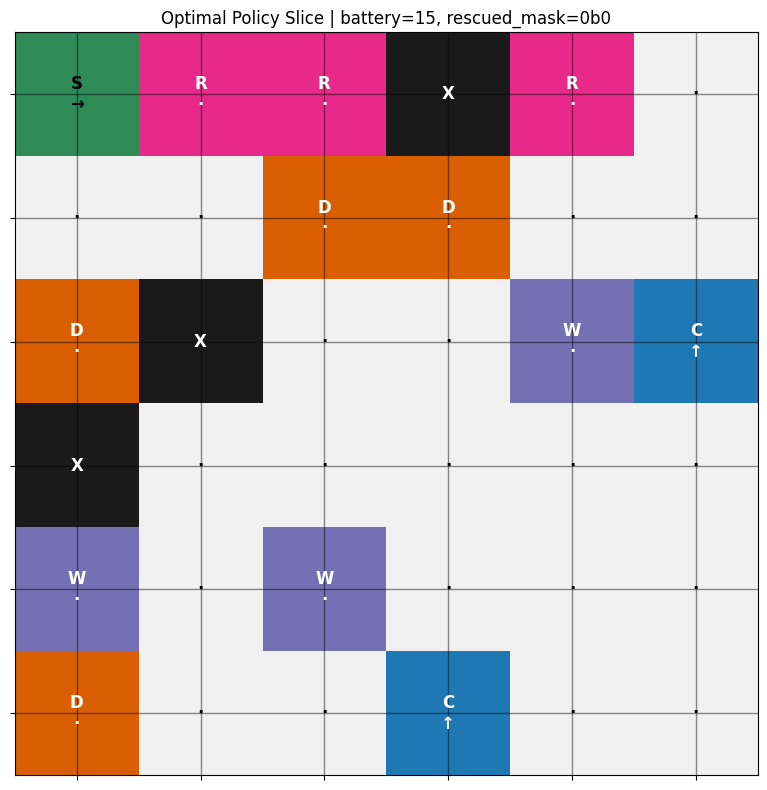

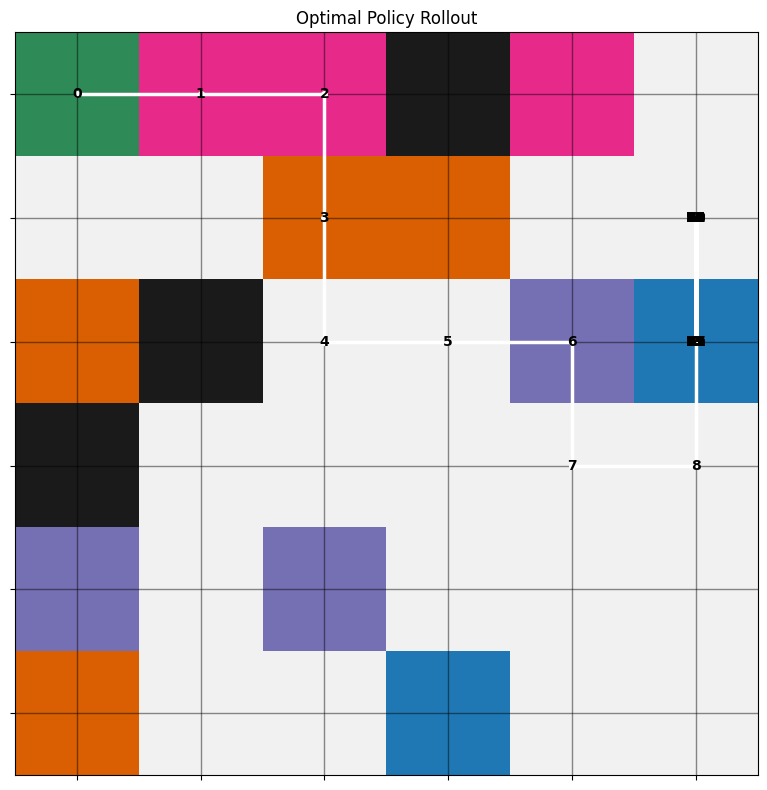

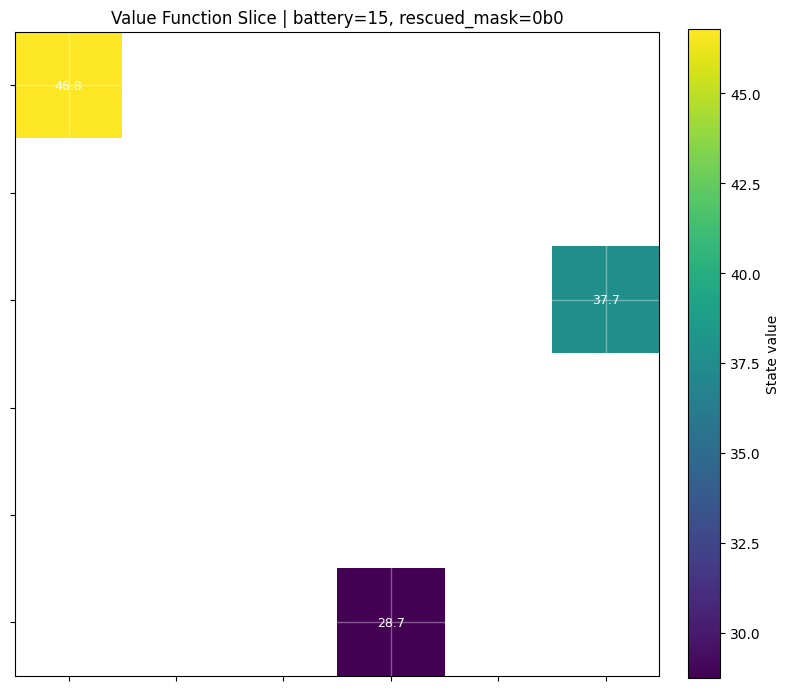


Optimal rollout summary:
  Steps taken        : 75
  Total rollout reward: 125.000
  Rescued civilians   : 2 / 3
  Final battery       : 15
  Final position      : (2, 5)

Saved policy slice to  : outputs\dp_notebook\dp_policy_slice.png
Saved rollout plot to  : outputs\dp_notebook\dp_optimal_rollout.png
Saved heatmap to       : outputs\dp_notebook\dp_value_heatmap.png

Scalability discussion:
Curse of dimensionality:
* If the grid expands from 5x5 or 6x6 to 10x10, the position component alone grows from
  25/36 cells to 100 cells, which multiplies the state count immediately.
* Each additional rescue target doubles the mask dimension, because the target status is
  part of the MDP state. Three targets already create 2^3 = 8 rescue-status combinations;
  five targets would create 32.
* If weather becomes dynamic instead of being attached to fixed wind cells, the transition
  model must include the weather state as well, which further increases the state space.

Why DP becomes difficult

In [38]:

IDENTIFIER = "129"  # Replace with your group ID or first student's register number.
OUTPUT_DIR = Path("outputs") / "dp_notebook"

dp_results = run_dp_workflow(
            identifier=IDENTIFIER,
            output_dir=OUTPUT_DIR,
            gamma=0.95,
            theta=1e-3,
            show_plots=True,
        )
        


## Scalability discussion

Use the printed discussion from the notebook output as the basis for the written report section.

Key points to mention:
- the state space grows quickly with larger grids
- each extra rescue target doubles the rescue-status combinations
- dynamic weather or richer motion uncertainty makes exact DP harder
- deep reinforcement learning becomes attractive when exact state enumeration is too expensive
